# Distance Metrics in KNN: Why Euclidean Isn't Always the Answer

---

## Learning Objectives

1. **Explain** how KNN uses distance to classify new data points
2. **Compare** the geometry of Euclidean, Manhattan, and Minkowski distances
3. **Demonstrate** how distance metric choice changes classification boundaries and outcomes
4. **Understand** why feature scaling is critical for all distance-based methods
5. **Choose** the right distance metric based on data characteristics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

CB_COLOURS = ['#0072B2', '#D55E00', '#009E73', '#F0E442', '#CC79A7', '#56B4E9']
MARKERS = ['o', 's', '^']
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11

FIG_DIR = '../figures'
import os; os.makedirs(FIG_DIR, exist_ok=True)
print("Setup complete.")

ModuleNotFoundError: No module named 'sklearn'

## 1. How KNN Works (Brief Recap)

K-Nearest Neighbours (KNN) is beautifully simple: to classify a new point, find the K closest points in the training data and let them vote. The majority class wins. There is no explicit "training" phase — the algorithm simply memorises the training data and does all the work at prediction time.

But here is the critical question most tutorials overlook: **what does "closest" mean?** The answer depends entirely on the **distance metric** you choose. Change the metric, and you change which points are considered neighbours, which changes the vote, which changes the prediction. In this tutorial, we explore exactly how.

In [ ]:
# Load Wine dataset (sklearn built-in — reliable, no download needed)
wine = load_wine()
X_full = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
class_names = wine.target_names

print(f"Dataset: {X_full.shape[0]} samples, {X_full.shape[1]} features")
print(f"Classes: {list(class_names)} with counts {np.bincount(y)}")
print(f"\nFeature ranges (showing why scaling matters):")
for col in X_full.columns[:5]:
    print(f"  {col}: [{X_full[col].min():.1f}, {X_full[col].max():.1f}]")

Dataset: 178 samples, 13 features
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')] with counts [59 71 48]

Feature ranges (showing why scaling matters):
  alcohol: [11.0, 14.8]
  malic_acid: [0.7, 5.8]
  ash: [1.4, 3.2]
  alcalinity_of_ash: [10.6, 30.0]
  magnesium: [70.0, 162.0]


## 2. Dataset: Wine Classification

We use scikit-learn's built-in **Wine dataset** (178 samples, 13 chemical features, 3 wine classes). The features measure chemical properties like alcohol content, malic acid, and flavanoids.

**Why this dataset?** The features have wildly different scales — alcohol ranges from ~11 to ~15, while proline ranges from ~278 to ~1680. This makes it perfect for demonstrating why feature scaling is essential for distance-based methods. Without scaling, proline would dominate all distance calculations simply because its numbers are larger.

In [ ]:
# Preprocessing
# Select 2 features for 2D visualisation (best separating pair)
feat1, feat2 = 'flavanoids', 'proline'
X_2d = X_full[[feat1, feat2]].values

# Scale ALL features
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_full.values)

# Scale 2D subset
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Stratified splits
X_train_2d, X_test_2d, y_train, y_test = train_test_split(
    X_2d_scaled, y, test_size=0.2, random_state=SEED, stratify=y)
X_train_full, X_test_full, y_train_f, y_test_f = train_test_split(
    X_scaled_full, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"2D features: {feat1}, {feat2} (scaled)")
print(f"Train: {X_train_2d.shape[0]} | Test: {X_test_2d.shape[0]}")

2D features: flavanoids, proline (scaled)
Train: 142 | Test: 36


## 3. Distance Metrics: The Shape of "Nearness"

The three metrics we compare all belong to the **Minkowski family**:

- **Euclidean (p=2):** `d = √(Σ(xᵢ - yᵢ)²)` — straight-line distance. Creates **circular** neighbourhoods
- **Manhattan (p=1):** `d = Σ|xᵢ - yᵢ|` — "city block" distance. Creates **diamond** neighbourhoods
- **Minkowski (p=3):** `d = (Σ|xᵢ - yᵢ|³)^(1/3)` — creates **rounded square** neighbourhoods

The parameter `p` controls the shape of the neighbourhood. As p increases, the neighbourhood becomes more square-like, giving more weight to the single largest difference between features. As p decreases toward 1, the neighbourhood becomes more diamond-like, weighting all feature differences more equally.

**Key insight:** Changing the metric changes the *shape* of the neighbourhood, which changes *which points are considered nearest*, which changes the classification.

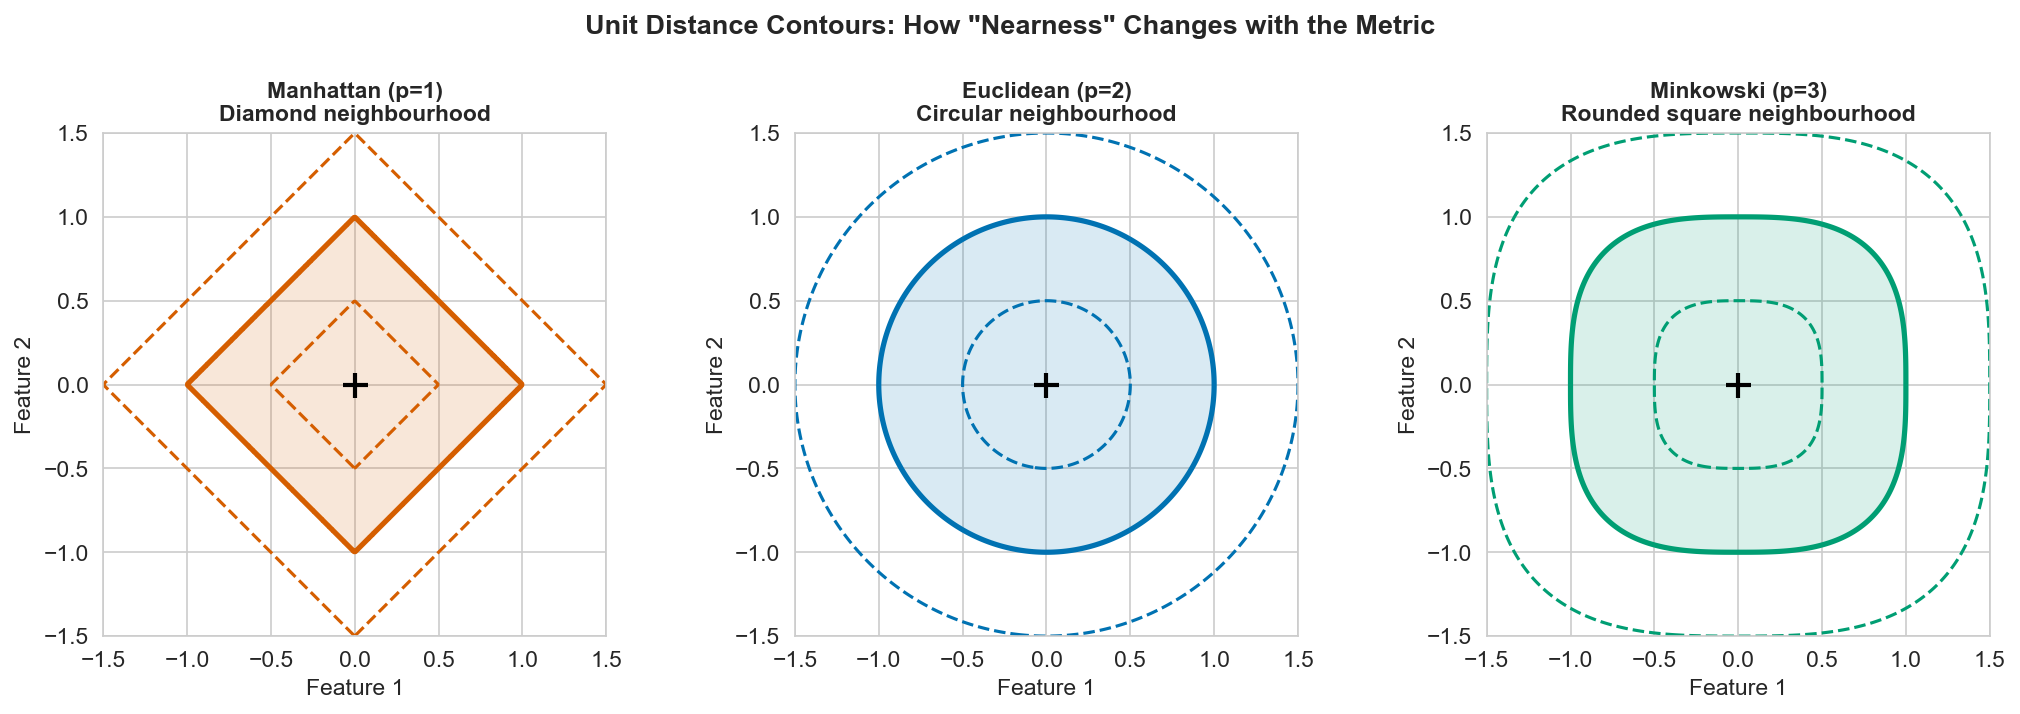

In [ ]:
# Distance Contour Plots — visualise neighbourhood shapes
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

p_values = [1, 2, 3]
titles = ['Manhattan (p=1)\nDiamond neighbourhood', 'Euclidean (p=2)\nCircular neighbourhood',
          'Minkowski (p=3)\nRounded square neighbourhood']
colours = [CB_COLOURS[1], CB_COLOURS[0], CB_COLOURS[2]]

x_grid = np.linspace(-1.5, 1.5, 400)
y_grid = np.linspace(-1.5, 1.5, 400)
xx, yy = np.meshgrid(x_grid, y_grid)

for ax, p_val, title, col in zip(axes, p_values, titles, colours):
    # Minkowski distance from origin
    dist = (np.abs(xx)**p_val + np.abs(yy)**p_val)**(1.0/p_val)
    
    # Filled contour for unit distance region
    ax.contourf(xx, yy, dist, levels=[0, 1], colors=[col], alpha=0.15)
    ax.contour(xx, yy, dist, levels=[0.5, 1.0, 1.5], colors=[col], linewidths=[1.5, 2.5, 1.5],
               linestyles=['--', '-', '--'])
    ax.plot(0, 0, 'k+', markersize=12, markeredgewidth=2)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('Unit Distance Contours: How "Nearness" Changes with the Metric',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/distance_contours.png', bbox_inches='tight', facecolor='white')
plt.show()

## 4. Neighbourhood Shapes: What the Contours Mean

The contour plots above show the **region of "equal distance"** from a central point under each metric:

- **Manhattan (diamond):** A point at (1,0) is equally "near" as (0,1). The metric treats differences in each dimension independently and sums them
- **Euclidean (circle):** The familiar straight-line distance. Points on the circle's boundary are equidistant from the centre
- **Minkowski p=3 (rounded square):** Gives more weight to the largest single-dimension difference, creating a bulging shape between circle and square

When KNN looks for the K nearest neighbours, it searches within these shapes. Different shapes mean **different points qualify as neighbours**, leading to different votes and potentially different classifications.

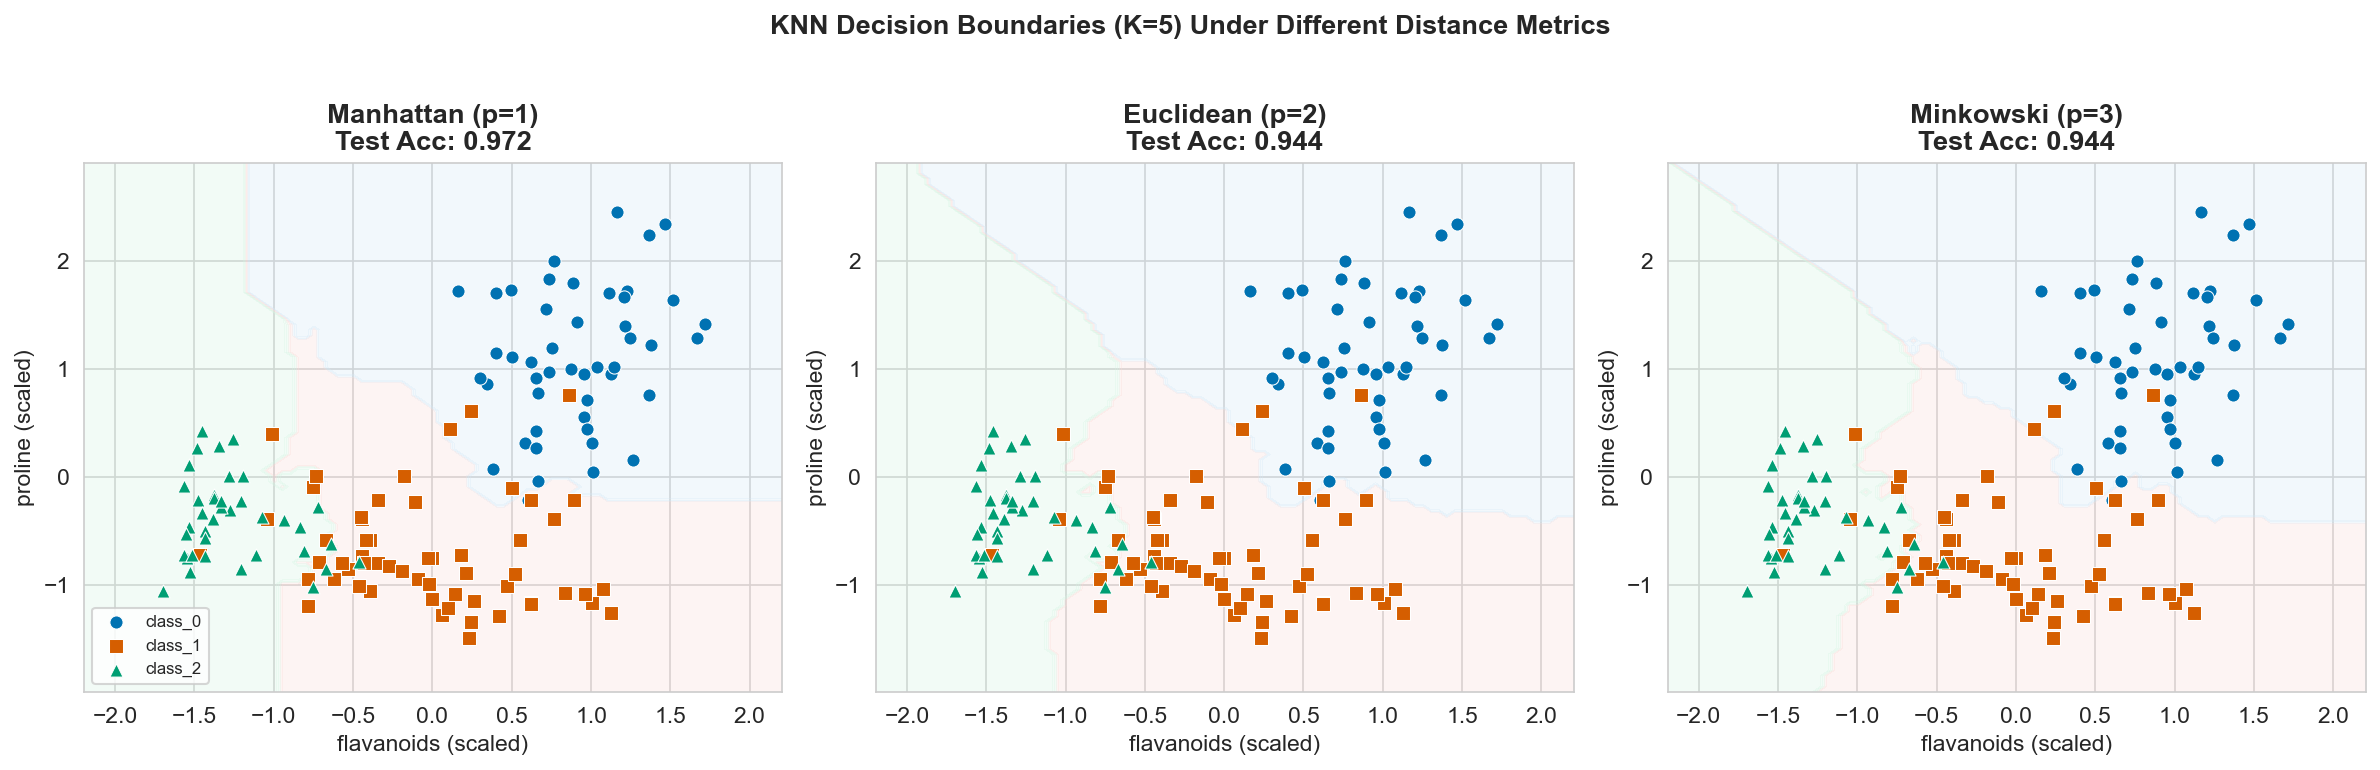

In [ ]:
# Decision Boundary Comparison — same data, 3 metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [('manhattan', 1, 'Manhattan (p=1)'), ('euclidean', 2, 'Euclidean (p=2)'),
           ('minkowski', 3, 'Minkowski (p=3)')]
K = 5
cmap_bg = ListedColormap(['#D6EAF8', '#FADBD8', '#D5F5E3'])
cmap_pts = ListedColormap(CB_COLOURS[:3])

# Create mesh for decision boundary
h = 0.05
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx_m, yy_m = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

for ax, (metric, p_val, title) in zip(axes, metrics):
    if metric == 'minkowski':
        knn = KNeighborsClassifier(n_neighbors=K, metric='minkowski', p=p_val)
    else:
        knn = KNeighborsClassifier(n_neighbors=K, metric=metric)
    knn.fit(X_train_2d, y_train)
    
    Z = knn.predict(np.c_[xx_m.ravel(), yy_m.ravel()]).reshape(xx_m.shape)
    ax.contourf(xx_m, yy_m, Z, alpha=0.3, cmap=cmap_bg)
    
    for cls in range(3):
        mask = y_train == cls
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                   c=CB_COLOURS[cls], marker=MARKERS[cls], s=40,
                   edgecolors='white', linewidth=0.5, label=class_names[cls])
    
    acc = accuracy_score(y_test, knn.predict(X_test_2d))
    ax.set_title(f'{title}\nTest Acc: {acc:.3f}', fontweight='bold')
    ax.set_xlabel(f'{feat1} (scaled)'); ax.set_ylabel(f'{feat2} (scaled)')
    if ax == axes[0]:
        ax.legend(fontsize=8, loc='lower left')

plt.suptitle(f'KNN Decision Boundaries (K={K}) Under Different Distance Metrics',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/boundary_comparison.png', bbox_inches='tight', facecolor='white')
plt.show()

## 5. How the Boundary Changes with the Metric

Compare the three decision boundary plots above. They use the **same data, same K, same features** — only the distance metric differs. Notice how:

- The regions have subtly different shapes at their borders
- Some test points near decision boundaries may be classified differently depending on the metric
- Accuracy varies because different neighbours are selected for borderline cases

This is not a minor implementation detail — for points near class boundaries, the metric choice determines the prediction.

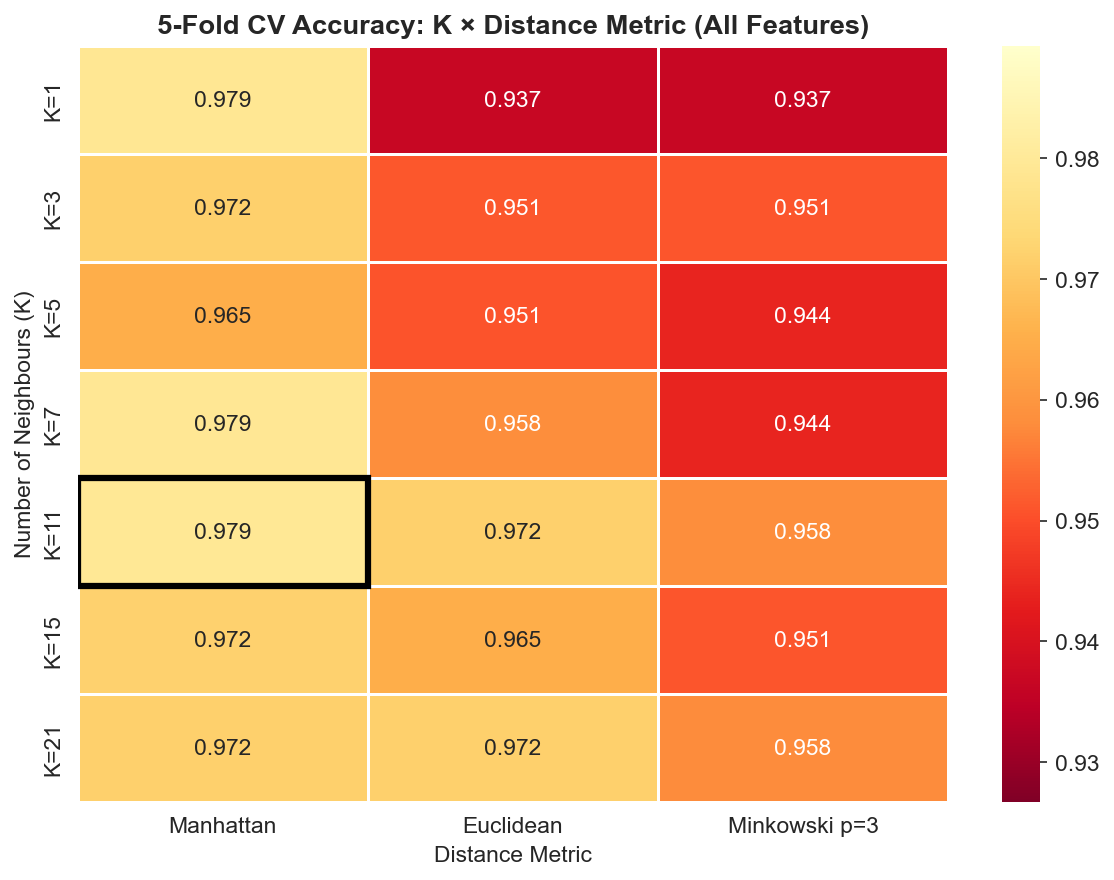

Best: K=11, Manhattan, accuracy=0.9793


In [ ]:
# Accuracy Heatmap: K × Metric grid (using ALL features)
K_values = [1, 3, 5, 7, 11, 15, 21]
metric_configs = [
    ('manhattan', {}, 'Manhattan'),
    ('euclidean', {}, 'Euclidean'),
    ('minkowski', {'p': 3}, 'Minkowski p=3'),
]

results = np.zeros((len(K_values), len(metric_configs)))

for i, k in enumerate(K_values):
    for j, (metric, params, name) in enumerate(metric_configs):
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, **params)
        scores = cross_val_score(knn, X_train_full, y_train_f, cv=5, scoring='accuracy')
        results[i, j] = scores.mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(results, annot=True, fmt='.3f', cmap='YlOrRd_r',
            xticklabels=[m[2] for m in metric_configs],
            yticklabels=[f'K={k}' for k in K_values],
            ax=ax, vmin=results.min()-0.01, vmax=results.max()+0.01,
            linewidths=0.5, linecolor='white')
ax.set_title('5-Fold CV Accuracy: K × Distance Metric (All Features)', fontweight='bold')
ax.set_xlabel('Distance Metric'); ax.set_ylabel('Number of Neighbours (K)')

# Mark best cell
best_idx = np.unravel_index(results.argmax(), results.shape)
ax.add_patch(plt.Rectangle((best_idx[1], best_idx[0]), 1, 1, fill=False,
             edgecolor='black', linewidth=3))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/metric_k_heatmap.png', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Best: K={K_values[best_idx[0]]}, {metric_configs[best_idx[1]][2]}, "
      f"accuracy={results[best_idx[0], best_idx[1]]:.4f}")

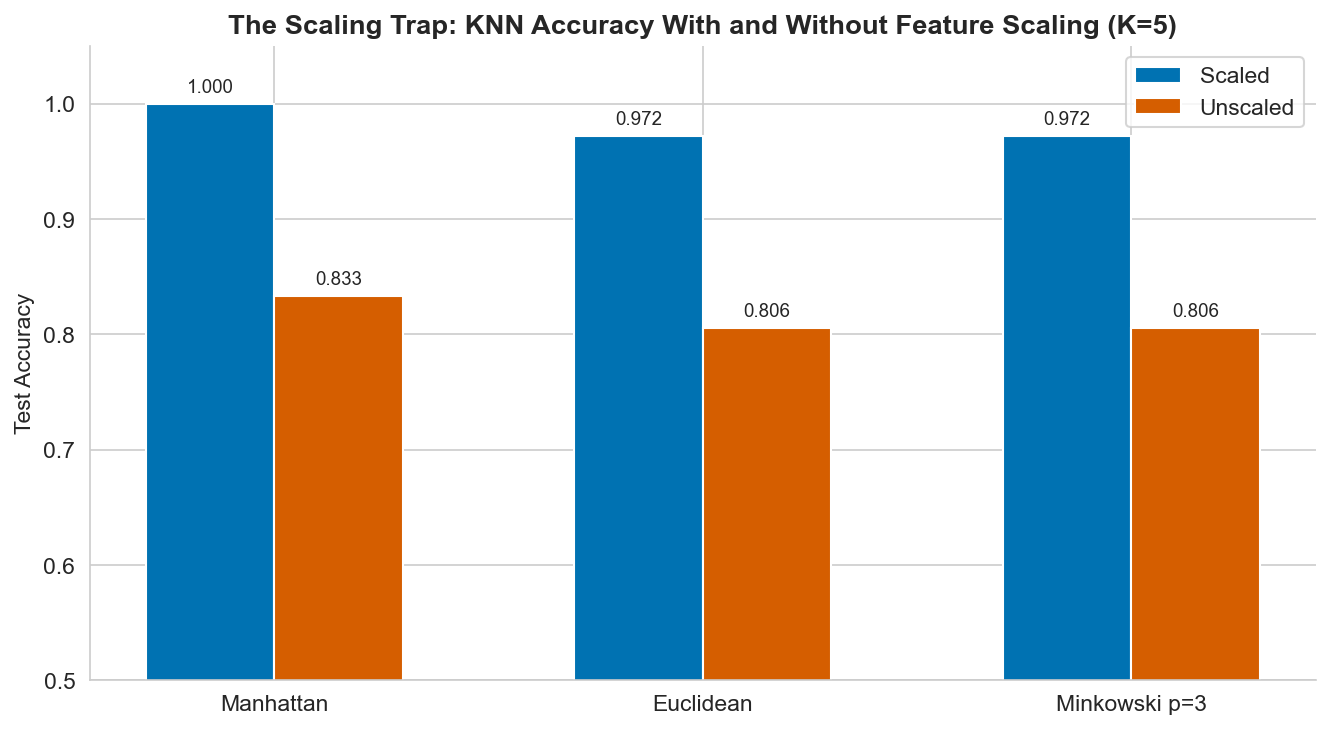

In [ ]:
# Feature Scaling Experiment — scaled vs unscaled
X_unscaled_train, X_unscaled_test, _, _ = train_test_split(
    X_full.values, y, test_size=0.2, random_state=SEED, stratify=y)

scaling_results = {}
for metric, params, name in metric_configs:
    # Scaled
    knn_s = KNeighborsClassifier(n_neighbors=5, metric=metric, **params)
    knn_s.fit(X_train_full, y_train_f)
    acc_s = accuracy_score(y_test_f, knn_s.predict(X_test_full))
    
    # Unscaled
    knn_u = KNeighborsClassifier(n_neighbors=5, metric=metric, **params)
    knn_u.fit(X_unscaled_train, y_train_f)
    acc_u = accuracy_score(y_test_f, knn_u.predict(X_unscaled_test))
    
    scaling_results[name] = {'Scaled': acc_s, 'Unscaled': acc_u}

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(metric_configs))
width = 0.3

bars1 = ax.bar(x_pos - width/2, [scaling_results[m[2]]['Scaled'] for m in metric_configs],
               width, label='Scaled', color=CB_COLOURS[0], edgecolor='white')
bars2 = ax.bar(x_pos + width/2, [scaling_results[m[2]]['Unscaled'] for m in metric_configs],
               width, label='Unscaled', color=CB_COLOURS[1], edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels([m[2] for m in metric_configs])
ax.set_ylabel('Test Accuracy')
ax.set_title('The Scaling Trap: KNN Accuracy With and Without Feature Scaling (K=5)',
             fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/scaling_effect.png', bbox_inches='tight', facecolor='white')
plt.show()

## 6. The Scaling Trap

The bar chart above demonstrates a critical lesson: **without feature scaling, KNN accuracy drops significantly** for all metrics. This happens because features with larger numerical ranges (like proline: 278–1680) dominate the distance calculation, while features with smaller ranges (like alcohol: 11–15) become effectively invisible.

After standardisation, all features contribute equally to distance calculations. This is not optional for distance-based methods — it is essential. Among the metrics, Manhattan distance tends to be slightly less sensitive to outliers due to its linear (non-squared) treatment of differences, but all metrics require scaling.

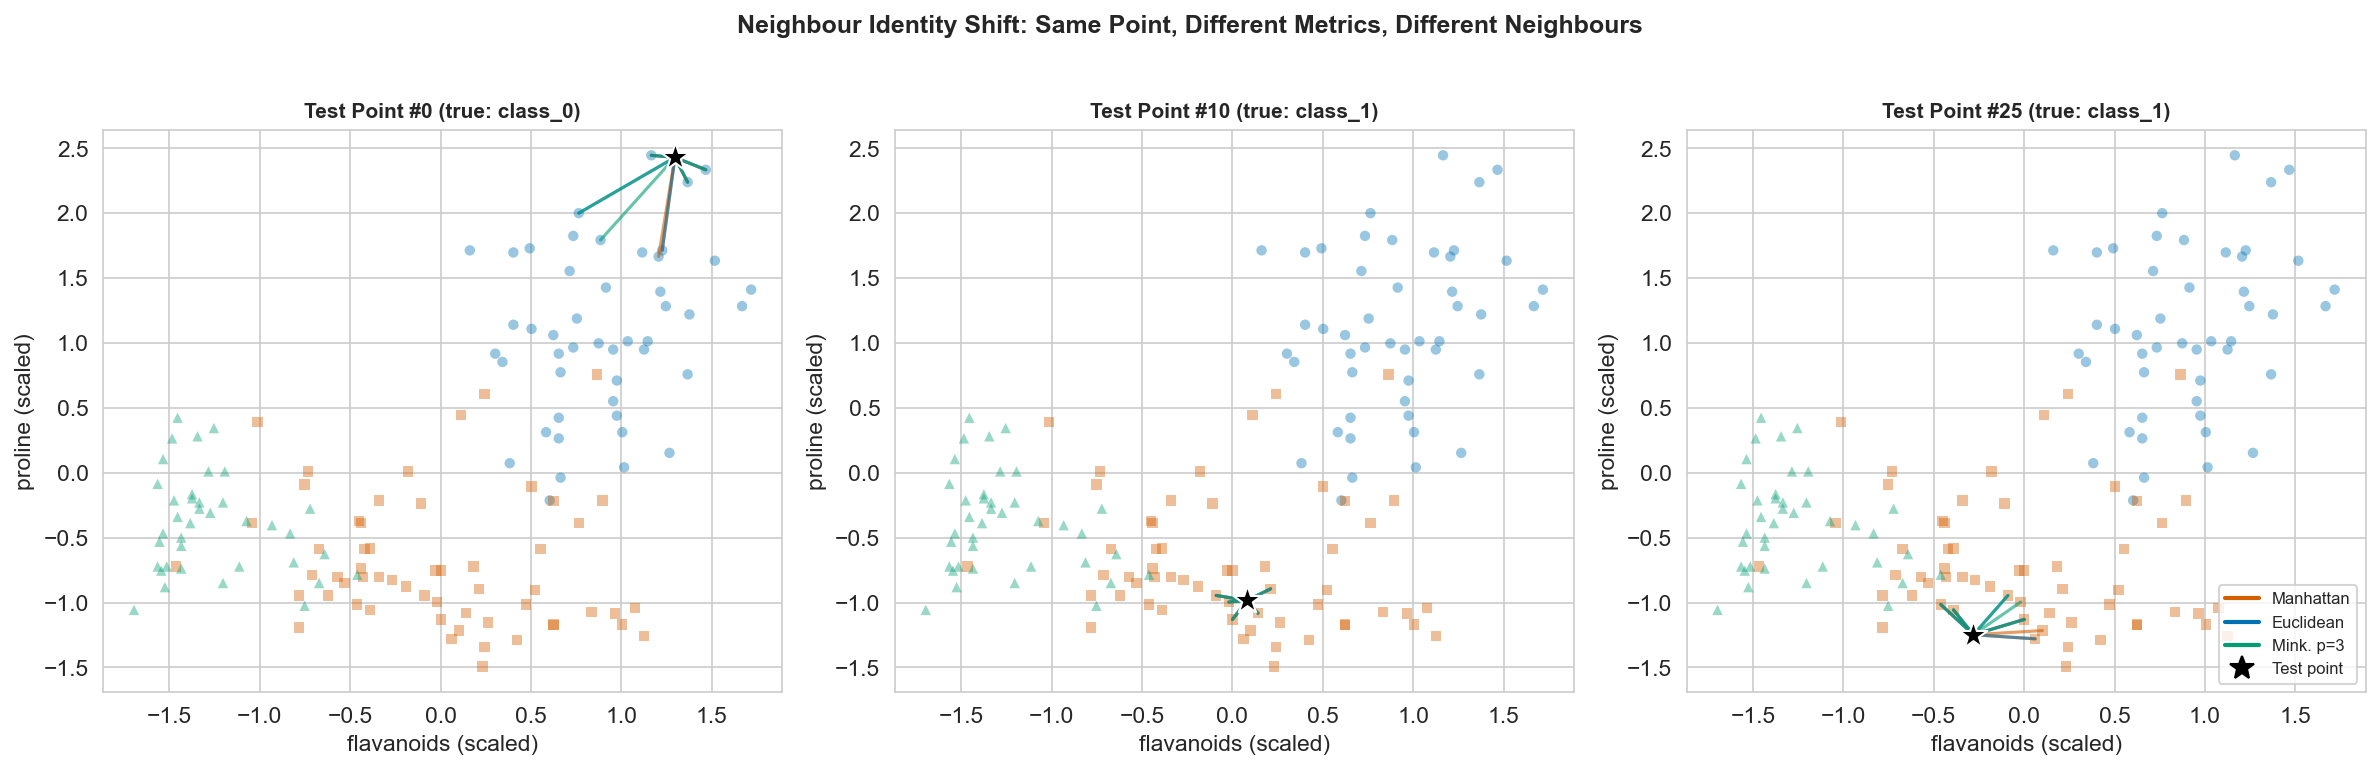

In [ ]:
# Neighbour Identity Shift — show which neighbours change across metrics
from sklearn.neighbors import NearestNeighbors

# Pick 3 test points
test_indices = [0, 10, 25]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metric_list = [('manhattan', {}, 'Manhattan', CB_COLOURS[1]),
               ('euclidean', {}, 'Euclidean', CB_COLOURS[0]),
               ('minkowski', {'p': 3}, 'Mink. p=3', CB_COLOURS[2])]

for ax, t_idx in zip(axes, test_indices):
    test_pt = X_test_2d[t_idx]
    
    # Plot all training points
    for cls in range(3):
        mask = y_train == cls
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                   c=CB_COLOURS[cls], marker=MARKERS[cls], s=25, alpha=0.4,
                   edgecolors='none')
    
    # Plot test point
    ax.scatter(test_pt[0], test_pt[1], c='black', marker='*', s=200, zorder=10,
               edgecolors='white', linewidth=1)
    
    # Find 5 nearest neighbours under each metric and draw circles
    for metric, params, name, col in metric_list:
        nn = NearestNeighbors(n_neighbors=5, metric=metric, **params)
        nn.fit(X_train_2d)
        dists, indices = nn.kneighbors(test_pt.reshape(1, -1))
        
        # Draw connections
        for idx in indices[0]:
            ax.plot([test_pt[0], X_train_2d[idx, 0]],
                    [test_pt[1], X_train_2d[idx, 1]],
                    color=col, linewidth=1.5, alpha=0.6, linestyle='-')
    
    ax.set_title(f'Test Point #{t_idx} (true: {class_names[y_test[t_idx]]})',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel(f'{feat1} (scaled)'); ax.set_ylabel(f'{feat2} (scaled)')

# Manual legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], color=c, linewidth=2, label=n)
                   for _,_,n,c in metric_list]
legend_elements.append(Line2D([0],[0], marker='*', color='black', markersize=12,
                               linestyle='None', label='Test point'))
axes[2].legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.suptitle('Neighbour Identity Shift: Same Point, Different Metrics, Different Neighbours',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/neighbour_shift.png', bbox_inches='tight', facecolor='white')
plt.show()

## 7. Choosing a Distance Metric in Practice

| Scenario | Recommended Metric | Reason |
|----------|-------------------|--------|
| General purpose, no prior knowledge | **Euclidean** | Default, works well with scaled features |
| Features with many outliers | **Manhattan** | Less sensitive to large single-dimension differences |
| You suspect one dominant feature axis | **Minkowski (high p)** | Focuses on largest difference |
| High-dimensional data (many features) | **Manhattan** | Distances are more discriminative in high dimensions |
| Binary or categorical-like features | **Manhattan** | Counts total mismatches (like Hamming distance) |

**General advice:** Always start with Euclidean (it's the default for good reason), but if accuracy is disappointing, try Manhattan — it often performs surprisingly well, especially on datasets with outliers or many features.

## 8. Limitations

- **2D visualisation:** Decision boundaries are shown for 2 features only; the full 13-feature space behaves differently
- **Single dataset:** Results are specific to the Wine dataset; other domains may favour different metrics
- **Limited metrics:** We only tested Minkowski family; other distances (cosine, Mahalanobis, learned metrics) exist
- **Small dataset:** 178 samples is modest; larger datasets might show more pronounced metric effects

## 9. Ethical Considerations

Wine quality assessment involves inherent subjectivity — ratings come from human expert panels whose preferences may reflect cultural biases. A model trained on such data perpetuates those biases. In consumer-facing applications, users should understand that "quality" predictions reflect historical expert opinion, not objective truth. Additionally, automated quality grading could disadvantage small producers whose wine styles differ from the training data's norms.

## Accessibility Statement

- **Colour-blind friendly:** Okabe-Ito palette (#0072B2, #D55E00, #009E73) with distinct marker shapes (circle, square, triangle)
- **Decision boundaries:** Use light background fills distinguishable by brightness, not just hue
- **Contour plots:** Use line style variation (solid, dashed) alongside colour
- **High contrast:** White backgrounds, dark text, annotated values
- **Text summaries:** Key results printed as text alongside every visualisation

## References

1. Cover, T. & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Trans. on Information Theory*, 13(1), 21-27.
2. Aggarwal, C. C. et al. (2001). On the surprising behavior of distance metrics in high dimensional space. *ICDT 2001*.
3. Hastie, T. et al. (2009). *The Elements of Statistical Learning*. 2nd Ed. Springer. Chapter 13.
4. Scikit-learn: [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
5. Aeberhard, S. et al. (1992). Wine dataset. UCI ML Repository.